In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = (
    "https://raw.githubusercontent.com/DataTalksClub/"
    "machine-learning-zoomcamp/main/cohorts/2026/data/"
    "car_fuel_efficiency_2026.csv"
)

features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]
target = "fuel_efficiency_mpg"

df = pd.read_csv(url)
df = df[features + [target]].copy()

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


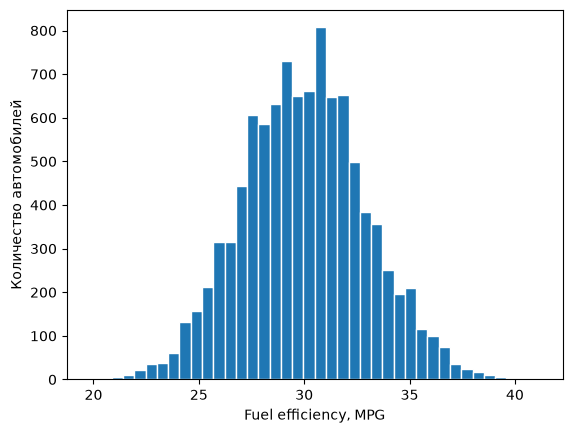

Пропуски:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Медиана horsepower: 254.0


In [3]:
plt.hist(df[target], bins=40, edgecolor="white")
plt.xlabel("Fuel efficiency, MPG")
plt.ylabel("Количество автомобилей")
plt.show()

print("Пропуски:")
print(df.isna().sum())

print("\nМедиана horsepower:", df["horsepower"].median())

In [4]:
def split_data(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    return df_train, df_val, df_test


df_train, df_val, df_test = split_data(df, seed=42)

print(len(df_train), len(df_val), len(df_test))

6000 2000 2000


In [5]:
def train_linear_regression(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    error = y - y_pred
    return np.sqrt(np.mean(error ** 2))


def evaluate(df_train, df_eval, fill_value=0, r=0):
    X_train = df_train[features].fillna(fill_value).to_numpy()
    y_train = df_train[target].to_numpy()

    X_eval = df_eval[features].fillna(fill_value).to_numpy()
    y_eval = df_eval[target].to_numpy()

    w0, w = train_linear_regression(X_train, y_train, r=r)
    y_pred = w0 + X_eval.dot(w)

    return rmse(y_eval, y_pred)

In [6]:
mean_horsepower = df_train["horsepower"].mean()

score_zero = evaluate(df_train, df_val, fill_value=0)
score_mean = evaluate(
    df_train,
    df_val,
    fill_value=mean_horsepower,
)

print("Среднее на train:", mean_horsepower)
print("With 0:", round(score_zero, 3))
print("With mean:", round(score_mean, 3))

Среднее на train: 254.46338337605272
With 0: 2.205
With mean: 2.202


In [7]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
scores_r = {}

for r in r_values:
    score = evaluate(df_train, df_val, fill_value=0, r=r)
    scores_r[r] = round(score, 4)
    print(f"r={r:<5} RMSE={score:.4f}")

best_r = min(scores_r, key=lambda r: (scores_r[r], r))
print("Лучший r:", best_r)

r=0     RMSE=2.2053
r=0.01  RMSE=2.2058
r=0.1   RMSE=2.2241
r=1     RMSE=2.3492
r=5     RMSE=2.4094
r=10    RMSE=2.4195
r=100   RMSE=2.4292
Лучший r: 0


In [8]:
seed_scores = []

for seed in range(10):
    train, val, test = split_data(df, seed=seed)

    score = evaluate(train, val, fill_value=0, r=0)
    seed_scores.append(score)

    print(f"seed={seed}: RMSE={score:.6f}")

std = np.std(seed_scores)

print("\nСтандартное отклонение:", std)
print("Ответ Q5:", round(std, 3))

seed=0: RMSE=2.239204
seed=1: RMSE=2.202113
seed=2: RMSE=2.163420
seed=3: RMSE=2.204359
seed=4: RMSE=2.201880
seed=5: RMSE=2.245785
seed=6: RMSE=2.269721
seed=7: RMSE=2.190795
seed=8: RMSE=2.216611
seed=9: RMSE=2.207037

Стандартное отклонение: 0.028781274078191175
Ответ Q5: 0.029


In [9]:
df_train, df_val, df_test = split_data(df, seed=9)

df_full_train = pd.concat(
    [df_train, df_val],
    ignore_index=True,
)

test_score = evaluate(
    df_full_train,
    df_test,
    fill_value=0,
    r=0.001,
)

print("Test RMSE:", test_score)
print("Ответ Q6:", round(test_score, 3))

Test RMSE: 2.235827747191731
Ответ Q6: 2.236


In [11]:
df_train, df_val, df_test = split_data(df, seed=9)
df_full_train = pd.concat([df_train, df_val], ignore_index=True)

X_train = df_full_train[features].fillna(0).to_numpy()
y_train = df_full_train[target].to_numpy()

w0, w = train_linear_regression(X_train, y_train, r=0.001)

X_test = df_test[features].fillna(0).to_numpy()
y_test = df_test[target].to_numpy()

y_pred = w0 + X_test.dot(w)

comparison = df_test[features].copy()
comparison["actual_mpg"] = y_test
comparison["predicted_mpg"] = y_pred
comparison["absolute_error"] = np.abs(y_test - y_pred)

comparison.head(10).round(2)

,engine_displacement,horsepower,vehicle_weight,model_year,actual_mpg,predicted_mpg,absolute_error
5463,2100,258.0,4060,2011,29.0,32.28,3.28
9878,2160,223.0,4130,2011,35.7,31.93,3.77
8503,2190,NaN,4030,1975,26.2,28.74,2.54
2571,2320,257.0,4640,1997,31.6,28.23,3.37
6851,2330,235.0,4130,1988,30.4,29.36,1.04
3197,2320,265.0,4050,1994,32.4,30.30,2.10
3088,2470,297.0,4470,1991,29.4,28.09,1.31
7627,2370,259.0,4410,2017,29.5,31.12,1.62
2025,2160,241.0,4050,1993,30.1,30.42,0.32
7816,2440,NaN,4290,1983,27.0,28.17,1.17
